### Step 1: Environment Setup & Data Loading

In [1]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Configure plot aesthetics
%matplotlib inline
sns.set_theme(style="whitegrid")

# Load dataset into Pandas DataFrame
# Handling potential encoding issues common with this dataset
df = pd.read_csv('data/OnlineRetail.csv', encoding='ISO-8859-1')

---

### Step 2: Dataset Selection & Documentation

*Documenting metadata requirements for deliverables (Notebook markdown & README).*

* **Dataset Name:** Online Retail Dataset
* **Source:** Kaggle / UCI Machine Learning Repository


* **Key Columns:** `InvoiceNo`, `StockCode`, `Description`, `Quantity`, `InvoiceDate`, `UnitPrice`, `CustomerID`, `Country`
* **Business Type:** UK-based online non-store retail selling giftware



---

### Step 3: Data Understanding

*Inspect structure, data types, dimensions, missing values, and summary statistics.*

In [2]:
# 1. Inspect dimensions (Rows, Columns)
print("Dataset Shape:", df.shape)


Dataset Shape: (541909, 8)


In [3]:
# 2. Inspect first few records
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [4]:
# 3. Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  str    
 1   StockCode    541909 non-null  str    
 2   Description  540455 non-null  str    
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  str    
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 67.3 MB


In [5]:
# 4. Check for missing values
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [6]:
# 5. Check for duplicate records
df.duplicated().sum()

np.int64(5268)

In [7]:
# 6. Basic statistical summary of numerical features
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


---

### Step 4: Data Cleaning

*Clean the dataset by dropping null customer IDs, removing cancelled orders (negative quantities), fixing data types, and handling duplicates.*

In [8]:
# 1. Remove duplicate rows
df.drop_duplicates(inplace=True)

In [9]:
# 2. Convert InvoiceDate to proper datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [10]:
# 3. Handle Missing CustomerIDs (filter or label as Guest)
# Dropping missing CustomerIDs for customer-specific analysis
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

In [11]:
# 4. Filter out negative/zero Quantities and UnitPrices (cancellations/returns start with 'C')
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0.001)]

In [12]:
df_clean.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,392688.000000,392688,392688.000000,392688.000000
mean,13.119825,2011-07-10 19:12:49.301277,3.125946,15287.848903
min,1.000000,2010-12-01 08:26:00,0.040000,12346.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000
std,180.493747,NaN,22.241947,1713.543619


In [13]:
# 5. Feature Engineering: Calculate Total Sales / Revenue per item
df_clean['TotalRevenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

In [14]:
# Verify cleaned dataset shape
print("Cleaned Dataset Shape:", df_clean.shape)

Cleaned Dataset Shape: (392688, 9)


---

### Step 5: Exploratory Data Analysis (EDA)

*Answering business questions using Pandas.*

In [15]:
# --- Sales Overview ---
total_revenue = df_clean['TotalRevenue'].sum()
total_orders = df_clean['InvoiceNo'].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Unique Orders: {total_orders:,}")
print(f"Average Order Value (AOV): ${avg_order_value:,.2f}")

Total Revenue: $8,887,208.89
Total Unique Orders: 18,532
Average Order Value (AOV): $479.56


In [16]:
# --- Product Insights ---
# Top 5 products by quantity sold
top_products_qty = df_clean.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(5)
top_products_qty

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
Name: Quantity, dtype: int64

In [17]:
# Top 5 products by revenue generated
top_products_rev = df_clean.groupby('Description')['TotalRevenue'].sum().sort_values(ascending=False).head(5)
top_products_rev

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
Name: TotalRevenue, dtype: float64

In [18]:
# --- Customer Insights ---
unique_customers = df_clean['CustomerID'].nunique()
unique_customers

4338

In [19]:
top_customers_spend = df_clean.groupby('CustomerID')['TotalRevenue'].sum().sort_values(ascending=False).head(5)
top_customers_spend

CustomerID
14646    280206.02
18102    259657.30
17450    194390.79
16446    168472.50
14911    143711.17
Name: TotalRevenue, dtype: float64

In [20]:
# --- Time Trends ---
# Extract Month-Year for temporal analysis
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')

In [21]:
monthly_sales = df_clean.groupby('YearMonth')['TotalRevenue'].sum()
monthly_sales

YearMonth
2010-12     570422.73
2011-01     568101.31
2011-02     446084.92
2011-03     594081.76
2011-04     468374.33
2011-05     677355.15
2011-06     660046.05
2011-07     598962.90
2011-08     644051.04
2011-09     950690.20
2011-10    1035642.45
2011-11    1156205.61
2011-12     517190.44
Freq: M, Name: TotalRevenue, dtype: float64

### Step 7: Basic Statistical Analysis

*Compute central tendency, dispersion, percentiles, and correlations.*

In [22]:
# Statistical summary for numerical fields
stats_df = df_clean[['Quantity', 'UnitPrice', 'TotalRevenue']]

In [23]:
# Mean, Median, Min, Max, Std Dev, Percentiles
descriptive_stats = stats_df.describe(percentiles=[0.25, 0.50, 0.75, 0.90, 0.95])
descriptive_stats

,Quantity,UnitPrice,TotalRevenue
count,392688.000000,392688.000000,392688.00000
mean,13.119825,3.125946,22.63173
std,180.493747,22.241947,311.10080
min,1.000000,0.040000,0.06000
25%,2.000000,1.250000,4.95000
50%,6.000000,1.950000,12.45000
75%,12.000000,3.750000,19.80000
90%,24.000000,6.350000,35.40000
95%,36.000000,8.500000,67.50000
max,80995.000000,8142.750000,168469.60000


In [24]:
# Correlation matrix
corr_matrix = stats_df.corr()
corr_matrix

,Quantity,UnitPrice,TotalRevenue
Quantity,1.000000,-0.004578,0.914451
UnitPrice,-0.004578,1.000000,0.081619
TotalRevenue,0.914451,0.081619,1.000000


---

### Step 8: Data Visualization

*Generate 6 to 8 visualizations using Matplotlib & Seaborn.*

(array([492]), [Text(492, 0, 'Jan\n2011')])

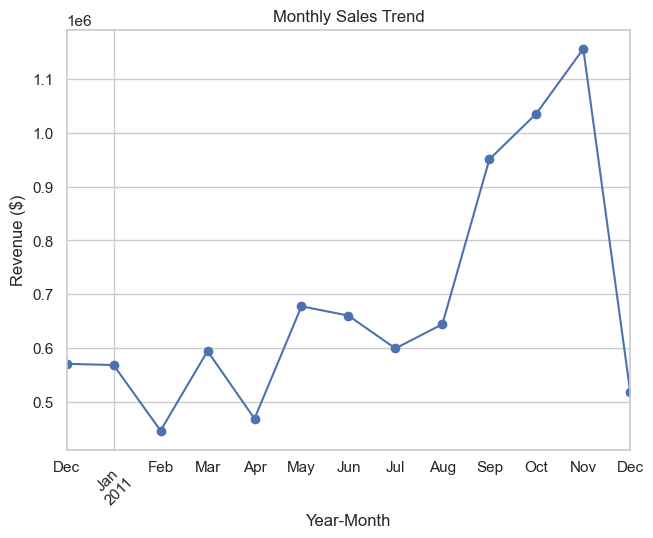

In [25]:
plt.figure(figsize=(16, 12))

# Chart 1: Monthly Sales Trend
plt.subplot(2, 2, 1)
monthly_sales.plot(kind='line', marker='o', color='b')
plt.title('Monthly Sales Trend')
plt.xlabel('Year-Month')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

Text(0.5, 0, 'Revenue ($)')

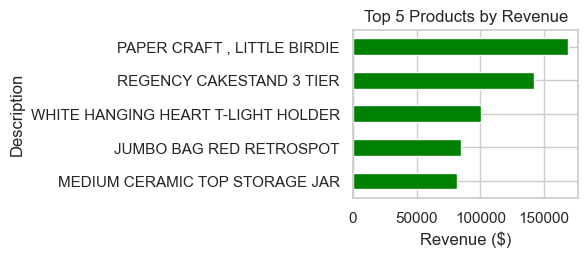

In [26]:
# Chart 2: Top 5 Products by Revenue
plt.subplot(2, 2, 2)
top_products_rev.plot(kind='barh', color='green').invert_yaxis()
plt.title('Top 5 Products by Revenue')
plt.xlabel('Revenue ($)')

Text(0.5, 0, 'Revenue ($)')

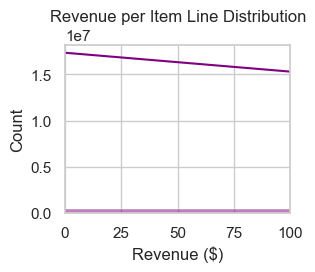

In [27]:
# Chart 3: Distribution of Order Total Revenue (log-transformed for visibility)
plt.subplot(2, 2, 3)
# Change this:
# sns.histplot(df_clean['TotalRevenue'], bins=50, kde=True, color='purple')

# To this:
sns.histplot(data=df_clean, x='TotalRevenue', bins=50, kde=True, color='purple')
plt.xlim(0, 100) # Cropped to focus on lower-end values
plt.title('Revenue per Item Line Distribution')
plt.xlabel('Revenue ($)')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13336\3552705296.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')


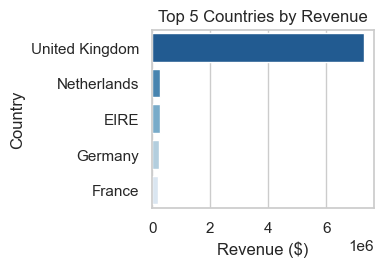

In [28]:
# Chart 4: Top 5 Countries by Revenue (Excluding UK for balance if needed)
plt.subplot(2, 2, 4)
top_countries = df_clean.groupby('Country')['TotalRevenue'].sum().sort_values(ascending=False).head(5)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Blues_r')
plt.title('Top 5 Countries by Revenue')
plt.xlabel('Revenue ($)')

plt.tight_layout()
plt.show()

Step 5: Customer Segmentation (RFM Analysis)

*Calculate Recency, Frequency, and Monetary value for each unique customer to group them into business-relevant tiers.*


In [29]:
# 1. Set reference date for Recency calculation (1 day after the latest purchase date in dataset)
import datetime as dt
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

In [30]:
# 2. Calculate RFM Metrics per Customer
rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalRevenue': 'sum'                                    # Monetary Value
}).reset_index()

# Rename columns clearly
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

In [31]:
# 3. Create RFM Scores (1 to 4 scale using quartiles)
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1]) # Lower recency is better (4)
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4])

# Combine individual scores into an overall RFM Segment
rfm['RFM_Group'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

In [32]:
# 4. Map Scores to Business Customer Segments
def assign_segment(df):
    if df['R_Score'] == 4 and df['F_Score'] == 4 and df['M_Score'] == 4:
        return 'Champions'
    elif df['F_Score'] >= 3 and df['M_Score'] >= 3:
        return 'Loyal Customers'
    elif df['R_Score'] >= 3 and df['F_Score'] <= 2:
        return 'Recent / New Customers'
    elif df['R_Score'] <= 2 and df['F_Score'] >= 3:
        return 'At Risk / Need Attention'
    else:
        return 'Lost / Inactive'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

# Display summary count per segment
print("Customer Segmentation Breakdown:")
print(rfm['Segment'].value_counts())

Customer Segmentation Breakdown:
Segment
Lost / Inactive             1710
Loyal Customers             1277
Recent / New Customers       665
Champions                    489
At Risk / Need Attention     197
Name: count, dtype: int64


Step 8: Customer Segment Plots

*Add plots to visualize segment counts and monetary contributions.*

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13336\2081714472.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Blues_r')


Text(0.5, 0, 'Number of Customers')

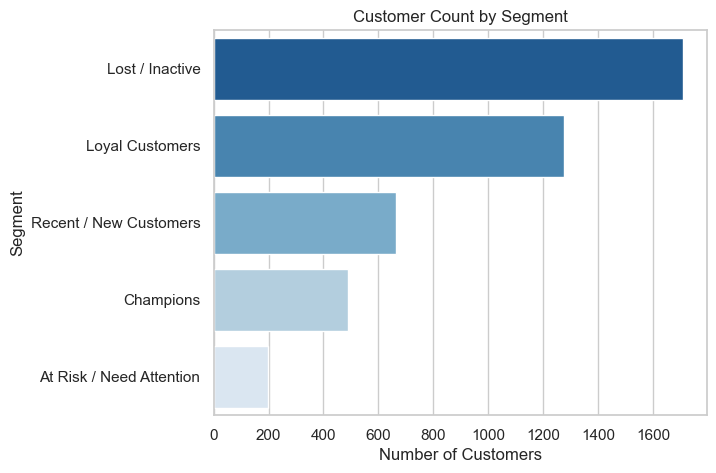

In [33]:
plt.figure(figsize=(14, 5))

# Plot 1: Count of Customers per Segment
plt.subplot(1, 2, 1)
segment_counts = rfm['Segment'].value_counts()
sns.barplot(x=segment_counts.values, y=segment_counts.index, palette='Blues_r')
plt.title('Customer Count by Segment')
plt.xlabel('Number of Customers')

C:\Users\ASUS\AppData\Local\Temp\ipykernel_13336\2516858558.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_revenue.values, y=segment_revenue.index, palette='Greens_r')


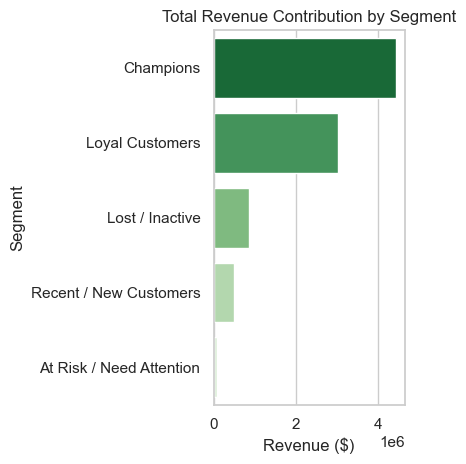

In [34]:
# Plot 2: Total Revenue Contribution by Segment
plt.subplot(1, 2, 2)
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)
sns.barplot(x=segment_revenue.values, y=segment_revenue.index, palette='Greens_r')
plt.title('Total Revenue Contribution by Segment')
plt.xlabel('Revenue ($)')

plt.tight_layout()
plt.show()

### Key Findings & Business Recommendations

**Key Finding:**

* **Customer Value Concentration:** The **Champions** and **Loyal Customers** segments make up a smaller percentage of total customers but contribute the majority of total business revenue. Conversely, **At Risk** customers hold significant historical spend but haven't ordered recently.

**Business Recommendation:**

* **Targeted Segment Marketing:** Launch automated email re-engagement campaigns with win-back discount codes specifically for **At Risk** customers, while providing early product access or exclusive loyalty rewards to **Champions** to boost lifetime retention.